In [25]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor,plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer,make_column_selector

from sklearn.metrics import accuracy_score,log_loss,r2_score

In [26]:
house=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\Housing.csv")
house

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,61000.0,6360,2,1,1,yes,no,no,no,no,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...
541,91500.0,4800,3,2,4,yes,yes,no,no,yes,0,no
542,94000.0,6000,3,2,4,yes,no,no,no,yes,0,no
543,103000.0,6000,3,2,4,yes,yes,no,no,yes,1,no
544,105000.0,6000,3,2,2,yes,yes,no,no,yes,1,no


In [27]:
X,y=house.drop("price",axis=1),house["price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=26)

In [28]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")
transf=ColumnTransformer(transformers=[("OHE",ohe, make_column_selector
                                        (dtype_include=object))],remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")
X_trn_ohe=transf.fit_transform(X_train)
X_tst_ohe=transf.transform(X_test)

In [30]:
depths=[1,2,3,5,None]
splits=[2,4,8,10,20,30,50,100]
leaves=[1,4,8,10,20,30,50,100]
scores=[]
for d in tqdm(depths):
    for s in splits:
        for l in leaves:
             dtc=DecisionTreeRegressor(random_state=26,min_samples_leaf=l,min_samples_split=s,max_depth=d)
             dtc.fit(X_trn_ohe,y_train)
             y_pred=dtc.predict(X_tst_ohe)
             scores.append([d,s,l,r2_score(y_test,y_pred)])
df_scores=pd.DataFrame(scores,columns=["depths","split","leaves","score"])
df_scores.sort_values("score", ascending=False)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.78it/s]


,depths,split,leaves,score
244,5.0,50,20,0.530931
308,NaN,50,20,0.530931
243,5.0,50,10,0.528372
242,5.0,50,8,0.528372
306,NaN,50,8,0.528372
...,...,...,...,...
28,1.0,10,20,0.320453
25,1.0,10,4,0.320453
24,1.0,10,1,0.320453
264,NaN,4,1,0.305639


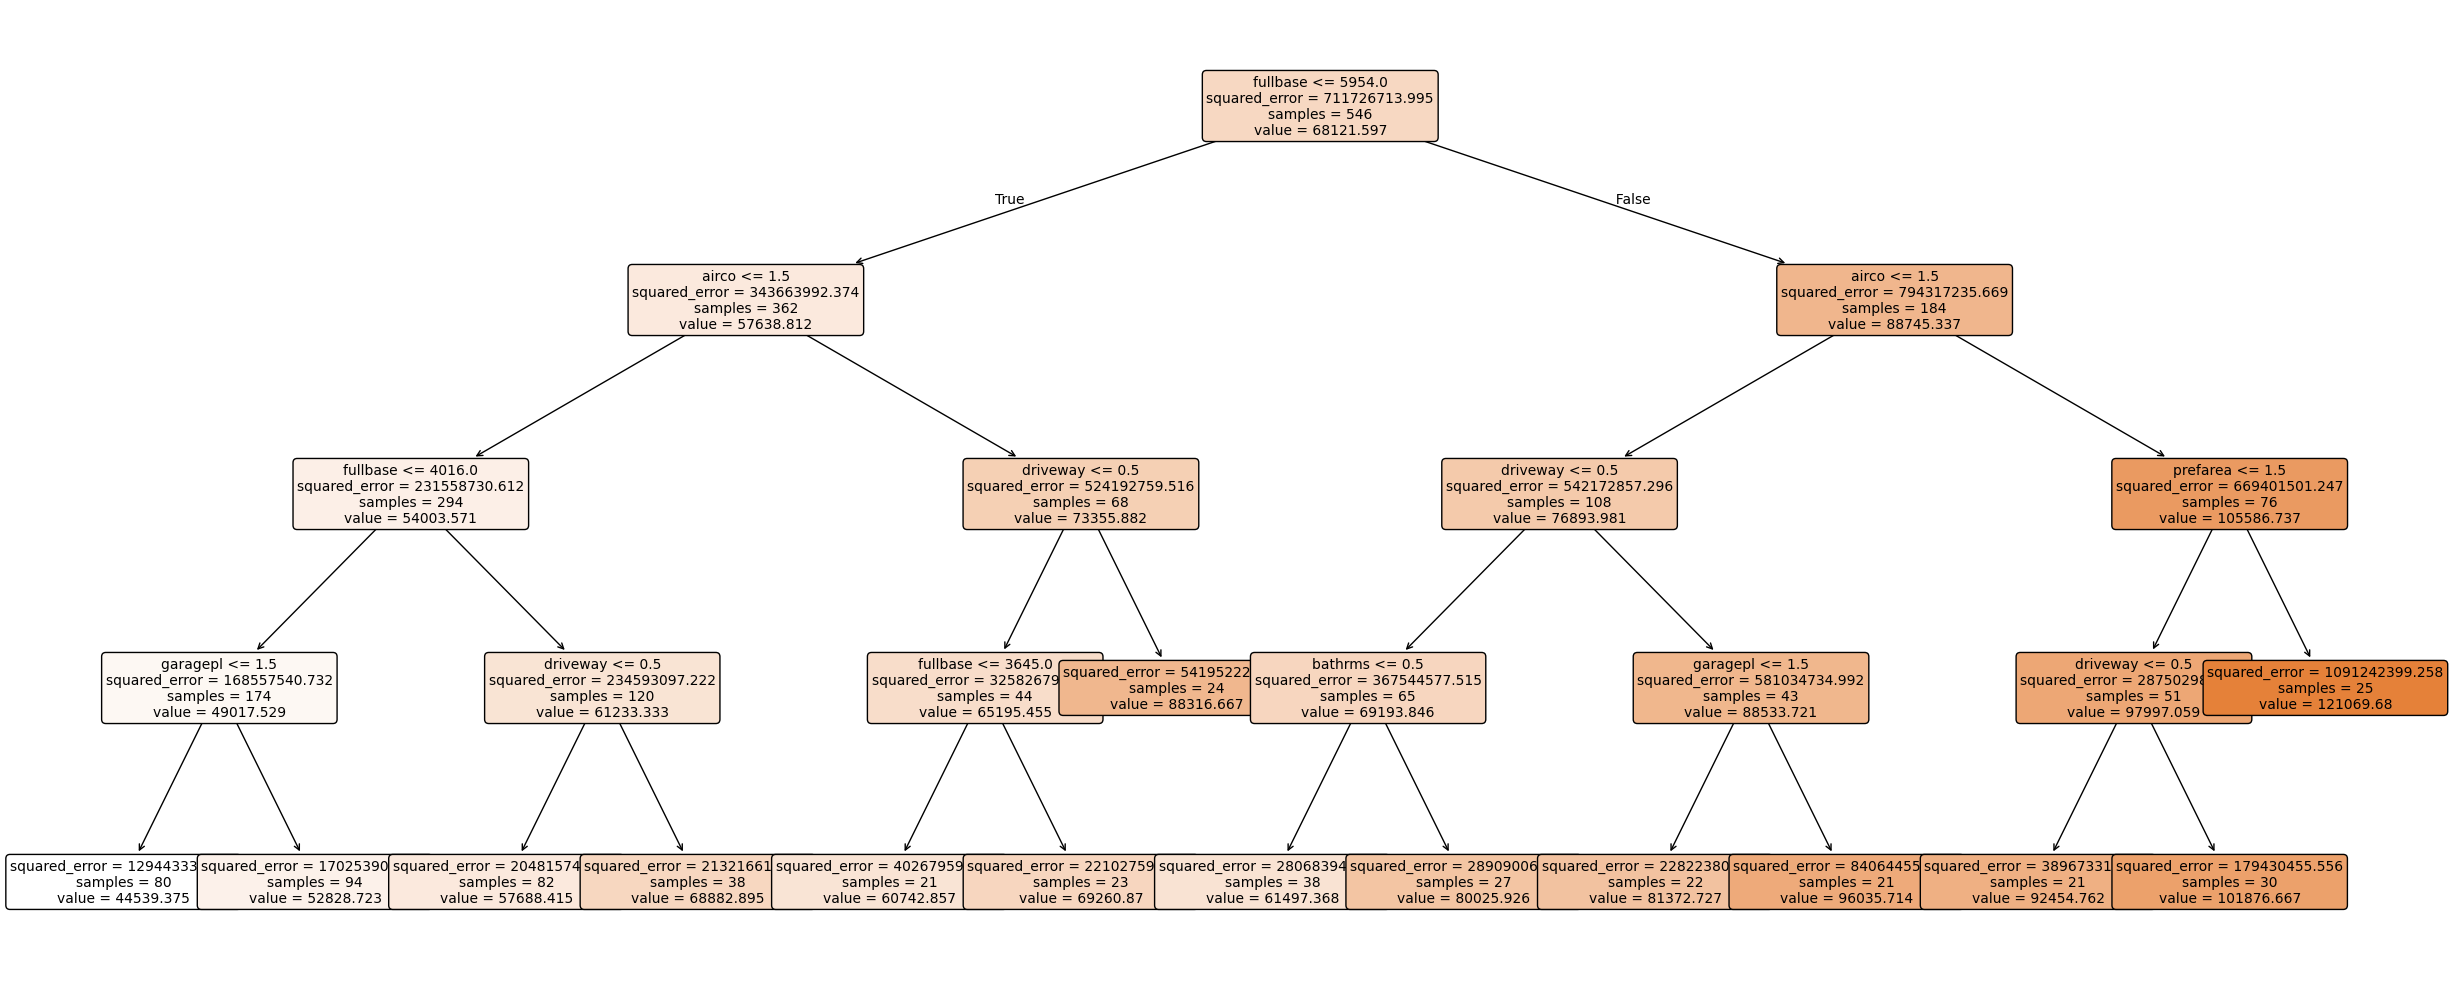

In [35]:
bm = DecisionTreeRegressor(random_state=26, min_samples_leaf=20, max_depth=4, min_samples_split=30)
X_ohe=transf.fit_transform(X)
bm.fit(X_ohe, y)
plt.figure(figsize=(25, 10))
plot_tree(bm, feature_names=list(X.columns), filled=True, fontsize=10,rounded=True)
plt.tight_layout()
plt.show()

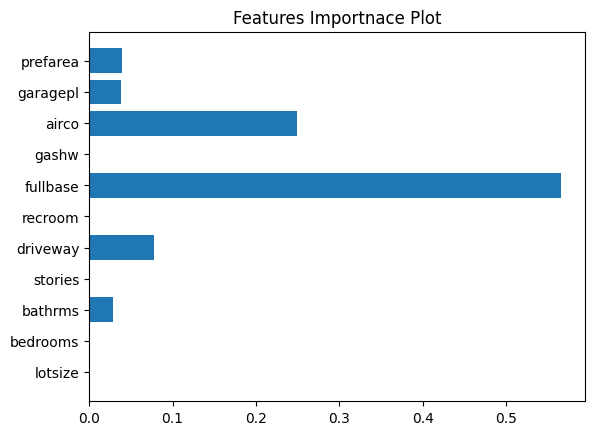

In [33]:
df_imp=pd.DataFrame({"feature":X.columns,"importance": bm.feature_importances_})
plt.barh(df_imp["feature"],df_imp["importance"])
plt.title("Features Importnace Plot")
plt.show()